In [1]:
import pandas as pd

In [2]:

train = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

In [3]:
display(stores.head())

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [4]:
display(features.head())

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [5]:
display(train.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [6]:
data = pd.merge(train, features, on=['Store', 'Date', 'IsHoliday'], how='left')

In [7]:
data = pd.merge(data, stores, on='Store', how='left')

In [8]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by=['Store', 'Dept', 'Date'])

In [9]:
display(data.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [10]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
data[markdown_cols] = data[markdown_cols].fillna(0)

In [11]:
data['Total_MarkDown'] = data['MarkDown1'] + data['MarkDown2'] + data['MarkDown3'] + data['MarkDown4'] + data['MarkDown5']

In [12]:
company_data = data.groupby('Date').agg({
    'Weekly_Sales': 'sum',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Total_MarkDown': 'mean',
    'IsHoliday': 'max' # If it's a holiday for one, it's a holiday for all
}).reset_index()

print("Data grouped! We now have", len(company_data), "weeks of total company data.")

Data grouped! We now have 143 weeks of total company data.


In [13]:
display(company_data)

,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Total_MarkDown,IsHoliday
0,2010-02-05,49750740.50,33.277942,2.717869,167.398405,0.000000,False
1,2010-02-12,48336677.63,33.361810,2.696102,167.384138,0.000000,True
2,2010-02-19,48276993.78,37.038310,2.673666,167.338966,0.000000,False
3,2010-02-26,43968571.13,38.629563,2.685642,167.691019,0.000000,False
4,2010-03-05,46871470.30,42.373998,2.731816,167.727351,0.000000,False
...,...,...,...,...,...,...,...
138,2012-09-28,43734899.40,68.151759,3.858245,175.919639,10858.516293,False
139,2012-10-05,47566639.31,65.456811,3.848435,175.998254,11486.792345,False
140,2012-10-12,46128514.25,57.687284,3.897425,176.123786,8138.880906,False
141,2012-10-19,45122410.57,60.152756,3.878413,176.295499,5667.852210,False


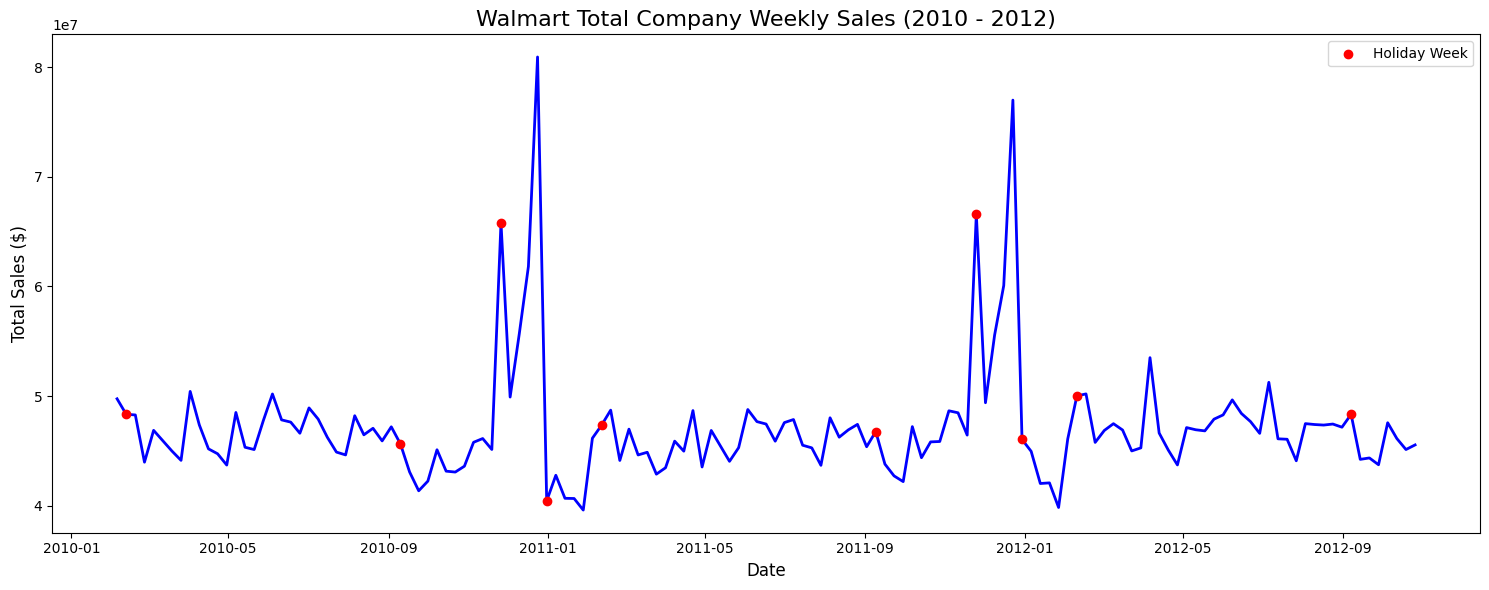

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(company_data['Date'], company_data['Weekly_Sales'], color='blue', linewidth=2)

plt.title('Walmart Total Company Weekly Sales (2010 - 2012)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

holidays = company_data[company_data['IsHoliday'] == True]
plt.scatter(holidays['Date'], holidays['Weekly_Sales'], color='red', label='Holiday Week', zorder=5)

plt.legend()
plt.tight_layout()
plt.show()

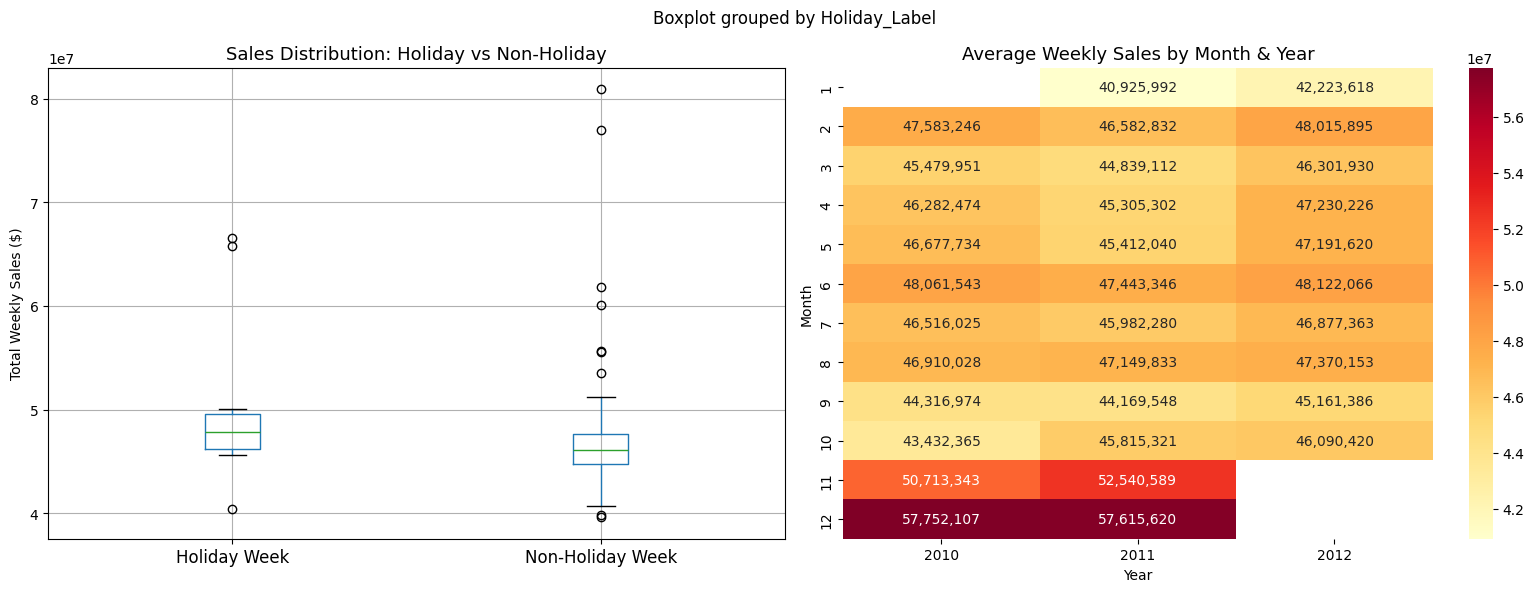


T-test: Holiday vs Non-Holiday Sales
  t-statistic: 2.0818
  p-value:     0.0392
  Conclusion:  Significant difference


In [15]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
company_data['Holiday_Label'] = company_data['IsHoliday'].map({True: 'Holiday Week', False: 'Non-Holiday Week'})
company_data.boxplot(column='Weekly_Sales', by='Holiday_Label', ax=axes[0])
axes[0].set_title('Sales Distribution: Holiday vs Non-Holiday', fontsize=13)
axes[0].set_ylabel('Total Weekly Sales ($)')
axes[0].set_xlabel('')
plt.sca(axes[0])
plt.xticks(fontsize=12)

# Monthly seasonality heatmap
company_data['Month'] = company_data['Date'].dt.month
company_data['Year'] = company_data['Date'].dt.year
pivot = company_data.pivot_table(values='Weekly_Sales', index='Month', columns='Year', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Average Weekly Sales by Month & Year', fontsize=13)

plt.tight_layout()
plt.show()

# T-test for statistical significance
from scipy.stats import ttest_ind
holiday_sales = company_data[company_data['IsHoliday'] == True]['Weekly_Sales']
non_holiday_sales = company_data[company_data['IsHoliday'] == False]['Weekly_Sales']
t_stat, p_val = ttest_ind(holiday_sales, non_holiday_sales)
print(f"\nT-test: Holiday vs Non-Holiday Sales")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_val:.4f}")
print(f"  Conclusion:  {'Significant difference' if p_val < 0.05 else 'No significant difference'}")

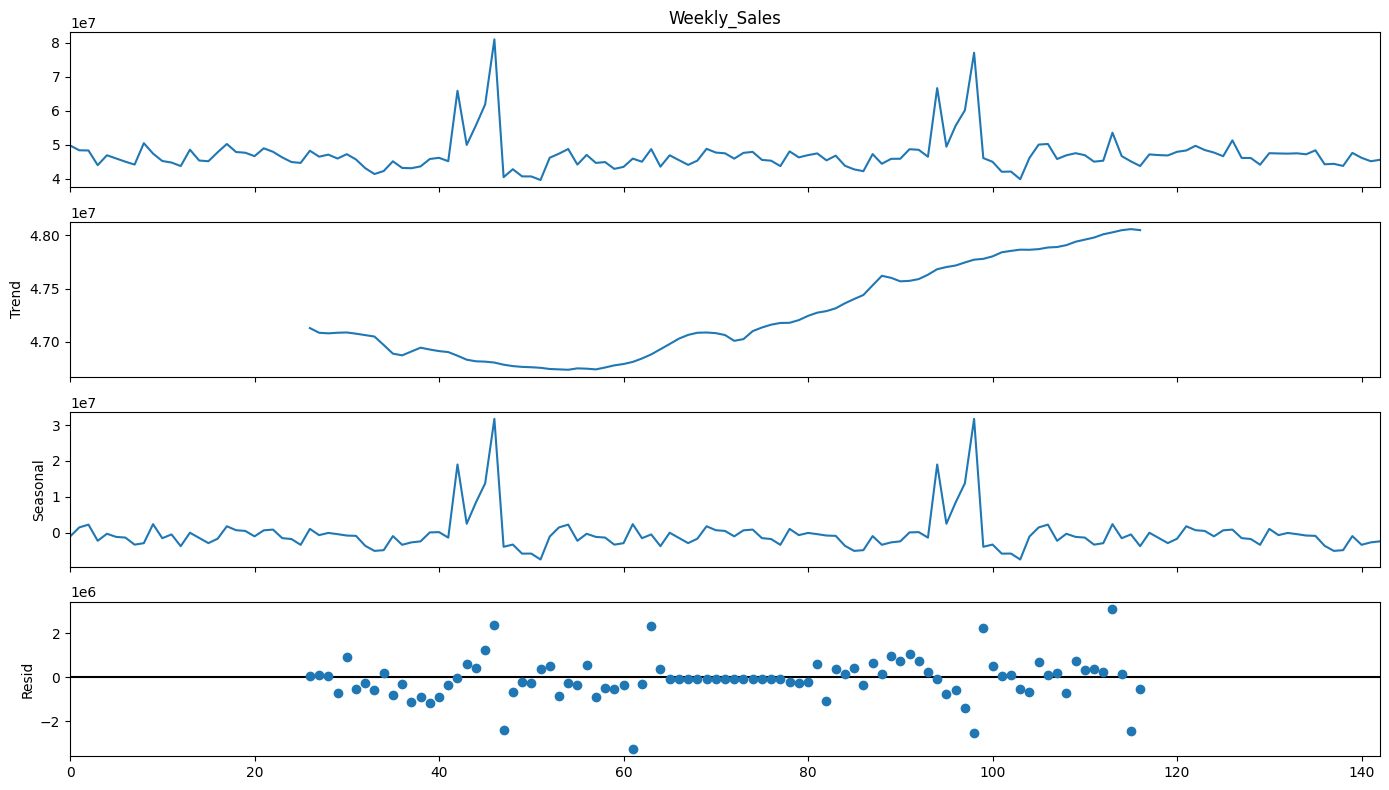

In [16]:
import statsmodels.api as sm

decomposition = sm.tsa.seasonal_decompose(company_data['Weekly_Sales'], model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

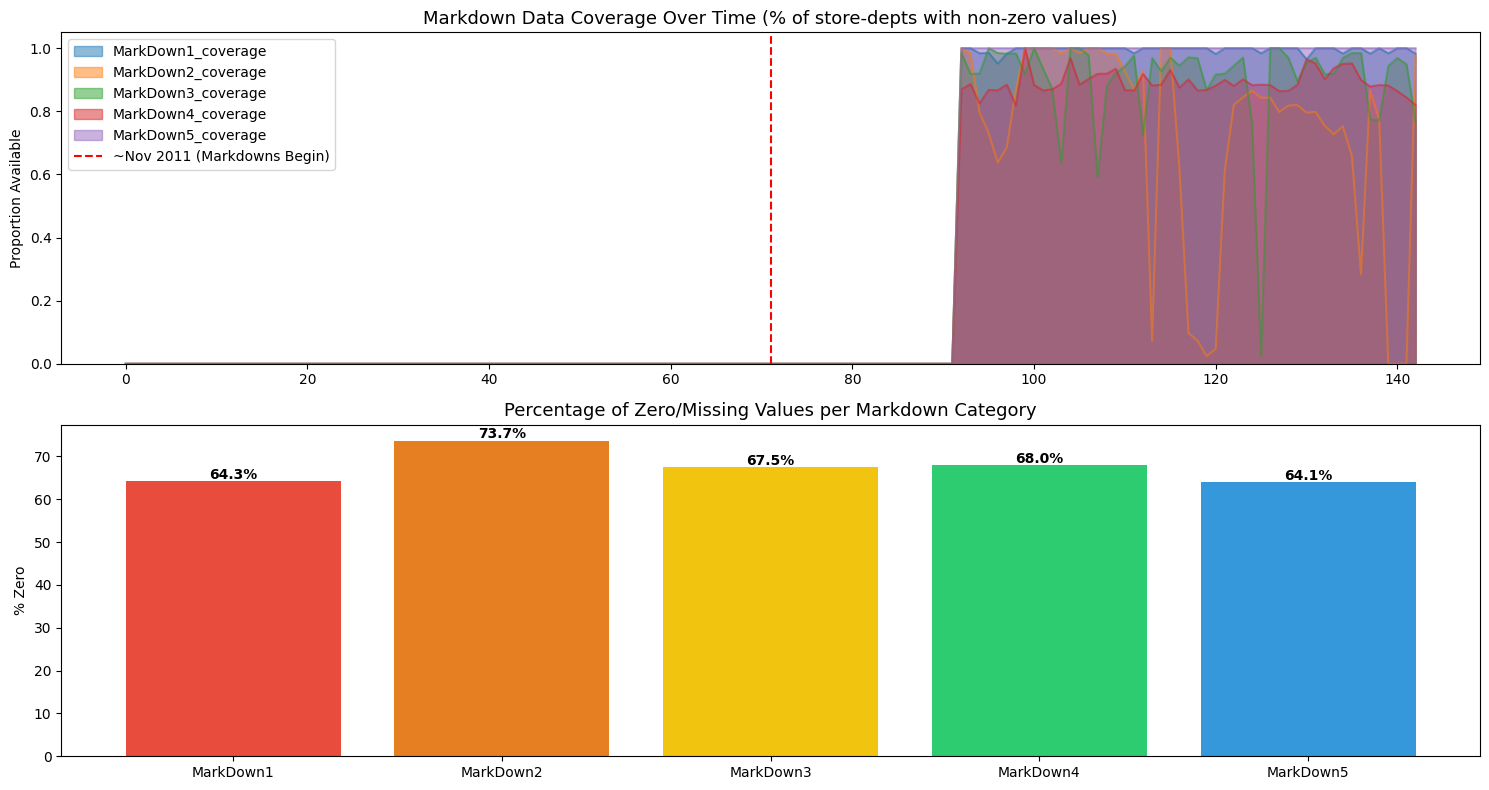

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# --- Sparsity Timeline ---
md_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
sparsity_df = company_data[['Date']].copy()
for col in md_cols:
    # Compute proportion of non-zero markdowns across stores for each date
    weekly = data.groupby('Date')[col].apply(lambda x: (x > 0).mean()).reset_index()
    weekly.columns = ['Date', f'{col}_coverage']
    sparsity_df = sparsity_df.merge(weekly, on='Date', how='left')

coverage_cols = [f'{c}_coverage' for c in md_cols]
sparsity_df[coverage_cols].plot(ax=axes[0], kind='area', stacked=False, alpha=0.5)
axes[0].set_title('Markdown Data Coverage Over Time (% of store-depts with non-zero values)', fontsize=13)
axes[0].set_ylabel('Proportion Available')
axes[0].axvline(x=sparsity_df.index[int(len(sparsity_df)*0.5)], color='red',
                linestyle='--', label='~Nov 2011 (Markdowns Begin)')
axes[0].legend()

# --- Overall Sparsity Bar Chart ---
zero_pcts = []
for col in md_cols:
    pct_zero = (data[col] == 0).mean() * 100
    zero_pcts.append(pct_zero)

bars = axes[1].bar(md_cols, zero_pcts, color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[1].set_title('Percentage of Zero/Missing Values per Markdown Category', fontsize=13)
axes[1].set_ylabel('% Zero')
for bar, pct in zip(bars, zero_pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

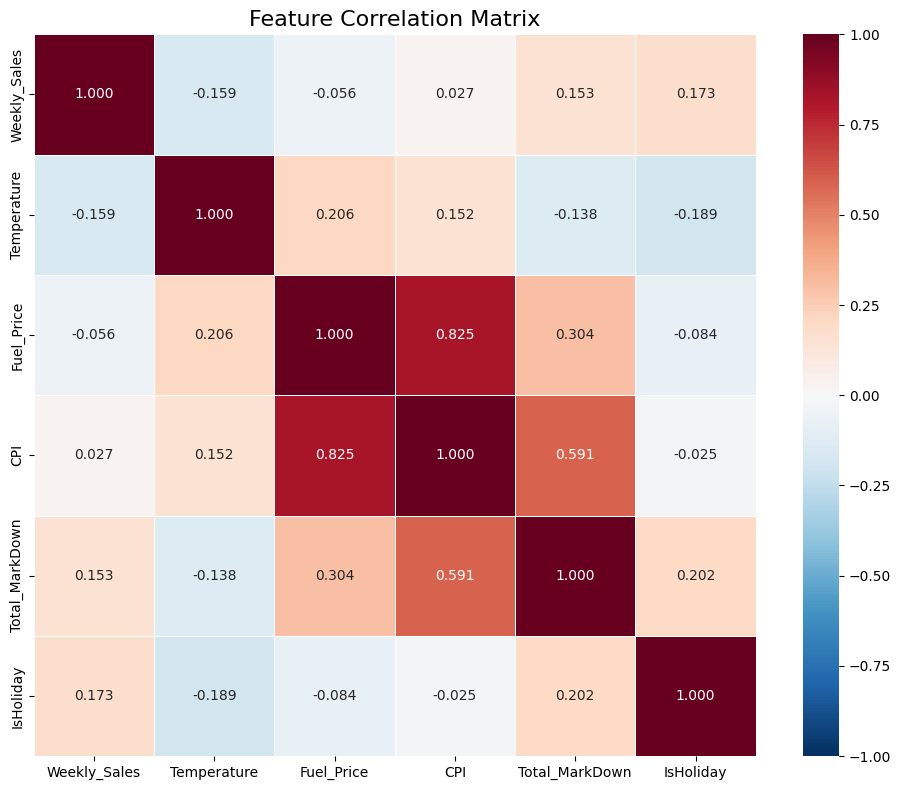


--- Variance Inflation Factors ---
(VIF > 10 indicates severe multicollinearity)
       Feature          VIF
         const 13280.461780
Total_MarkDown     1.960721
           CPI     5.311870
    Fuel_Price     3.736503
   Temperature     1.115837


In [18]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Correlation Heatmap ---
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
             'Total_MarkDown', 'IsHoliday']
corr_matrix = company_data[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# --- Variance Inflation Factor ---
exog_features = company_data[['Total_MarkDown', 'CPI', 'Fuel_Price', 'Temperature']].dropna()
exog_features = sm.add_constant(exog_features)

vif_data = pd.DataFrame()
vif_data['Feature'] = exog_features.columns
vif_data['VIF'] = [variance_inflation_factor(exog_features.values, i)
                   for i in range(exog_features.shape[1])]

print("\n--- Variance Inflation Factors ---")
print("(VIF > 10 indicates severe multicollinearity)")
print(vif_data.to_string(index=False))

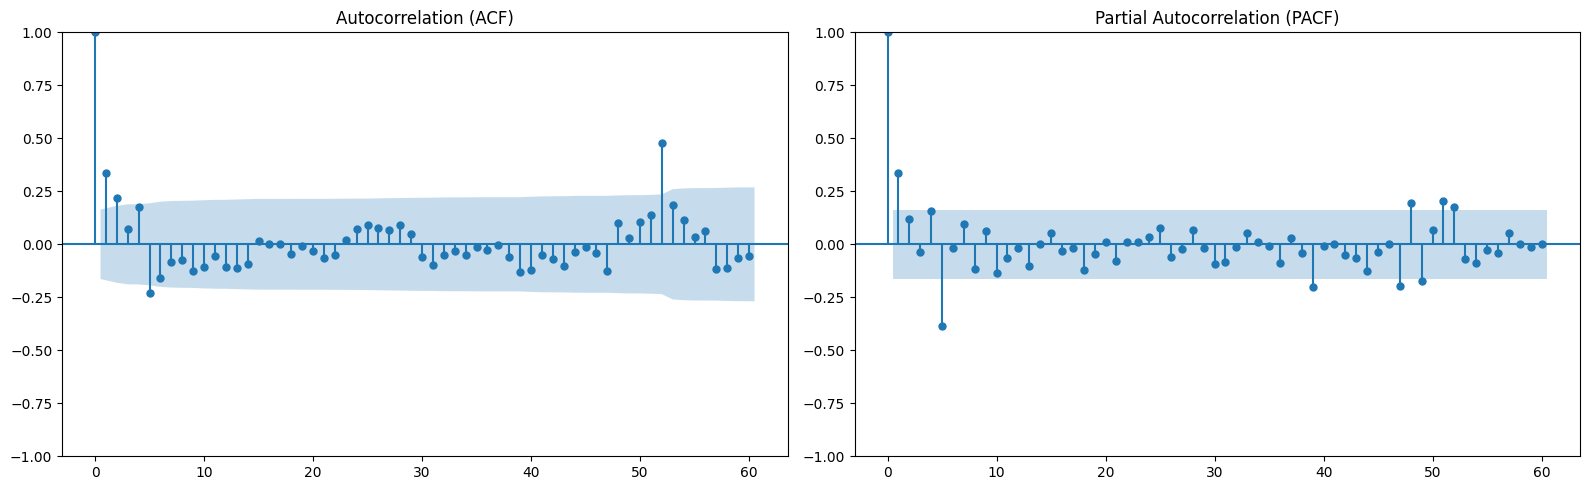

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(company_data['Weekly_Sales'], lags=60, ax=axes[0], title='Autocorrelation (ACF)')

plot_pacf(company_data['Weekly_Sales'], lags=60, ax=axes[1], title='Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

In [20]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(company_data['Weekly_Sales'])

print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')

if adf_result[1] <= 0.05:
    print("Conclusion: The data is stationary.")
else:
    print("Conclusion: The data is NOT stationary.")

ADF Statistic: -5.908297957186334
p-value: 2.675979158986027e-07
Conclusion: The data is stationary.



ADF on Differenced Series: Statistic=-6.6995, p-value=0.000000
Conclusion: Stationary after differencing


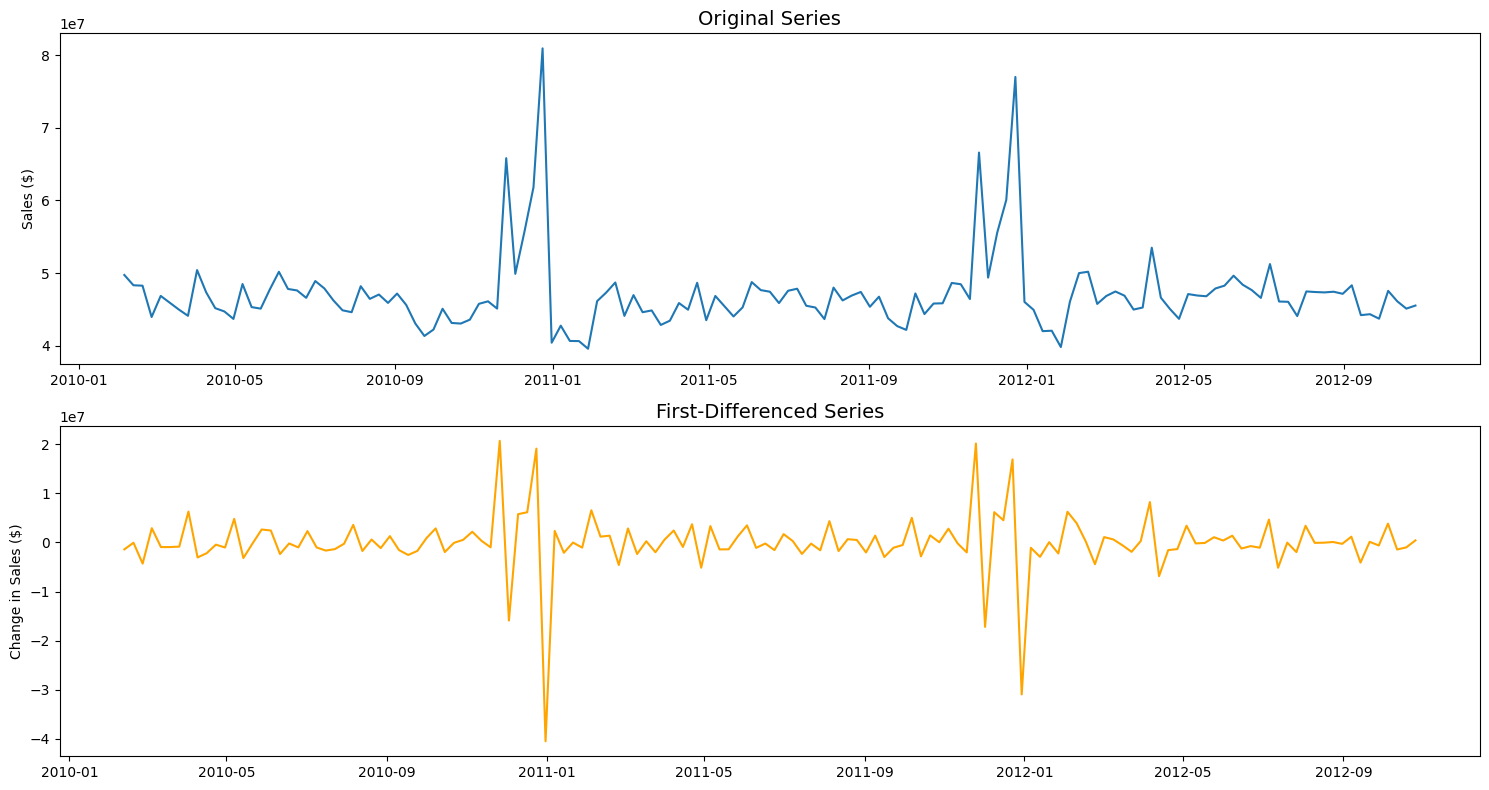

In [38]:
# First-difference
company_data['Weekly_Sales_diff'] = company_data['Weekly_Sales'].diff().dropna()

adf_diff = adfuller(company_data['Weekly_Sales_diff'].dropna())
print(f"\nADF on Differenced Series: Statistic={adf_diff[0]:.4f}, p-value={adf_diff[1]:.6f}")
print(f"Conclusion: {'Stationary after differencing' if adf_diff[1] <= 0.05 else 'Still non-stationary'}")

# Plot original vs differenced
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(company_data['Date'], company_data['Weekly_Sales'])
axes[0].set_title('Original Series', fontsize=14)
axes[0].set_ylabel('Sales ($)')

axes[1].plot(company_data['Date'].iloc[1:], company_data['Weekly_Sales_diff'].dropna(), color='orange')
axes[1].set_title('First-Differenced Series', fontsize=14)
axes[1].set_ylabel('Change in Sales ($)')
plt.tight_layout()
plt.show()

In [22]:
from statsmodels.tsa.stattools import grangercausalitytests

print("="*60)
print("GRANGER CAUSALITY TEST: Do Markdowns predict Sales?")
print("="*60)
print("H0: Markdowns do NOT Granger-cause Weekly Sales\n")

gc_data = company_data[['Weekly_Sales', 'Total_MarkDown']].dropna()
gc_result = grangercausalitytests(gc_data, maxlag=4, verbose=True)

# Summarize
print("\n--- Interpretation ---")
print("If p-values > 0.05 across all lags, markdowns have NO predictive")
print("power over sales → supports the Aggregation Paradox hypothesis.")

GRANGER CAUSALITY TEST: Do Markdowns predict Sales?
H0: Markdowns do NOT Granger-cause Weekly Sales


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2475  , p=0.6196  , df_denom=139, df_num=1
ssr based chi2 test:   chi2=0.2528  , p=0.6151  , df=1
likelihood ratio test: chi2=0.2526  , p=0.6152  , df=1
parameter F test:         F=0.2475  , p=0.6196  , df_denom=139, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2160  , p=0.2996  , df_denom=136, df_num=2
ssr based chi2 test:   chi2=2.5215  , p=0.2834  , df=2
likelihood ratio test: chi2=2.4992  , p=0.2866  , df=2
parameter F test:         F=1.2160  , p=0.2996  , df_denom=136, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.8546  , p=0.4665  , df_denom=133, df_num=3
ssr based chi2 test:   chi2=2.6987  , p=0.4404  , df=3
likelihood ratio test: chi2=2.6730  , p=0.4448  , df=3
parameter F test:         F=0.8546  , p=0.4665  , df_denom=133, df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [23]:
train_size = int(len(company_data) * 0.8)

train_data = company_data.iloc[:train_size]
test_data = company_data.iloc[train_size:]

In [24]:
!pip install pmdarima
from pmdarima import auto_arima

print("Training Baseline SARIMA Model... (Please wait, this tests many combinations)")

# Train the model strictly on historical sales (no external factors yet)
baseline_model = auto_arima(train_data['Weekly_Sales'],
                            seasonal=True,
                            m=52,             # 52 weeks in a year for seasonality
                            stepwise=True,    # Uses a smart search algorithm to save time
                            trace=True,       # Prints the progress as it tests different models
                            suppress_warnings=True)

print("\n--- Baseline Model Successfully Trained! ---")
# This prints the statistical summary of the winning model
print(baseline_model.summary())

Training Baseline SARIMA Model... (Please wait, this tests many combinations)
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=3834.201, Time=11.09 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3886.296, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=3856.182, Time=1.12 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=3852.847, Time=0.71 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=4356.183, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=3844.132, Time=4.29 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=3832.453, Time=7.11 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=3876.338, Time=0.28 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=3834.416, Time=32.85 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=3837.803, Time=45.30 sec
 ARIMA(1,0,2)(1,0,0)[52] intercept   : AIC=3838.876, Time=4.35 sec
 ARIMA(2,0,1)(1,0,0)[52] intercept   : AIC=3839.895, Time=5.15 sec
 ARIMA(3,0,2)(1,0,0)[52] intercept   : AIC=3833.656, Time=6.99 sec
 ARIM

Generating Residual Diagnostics...


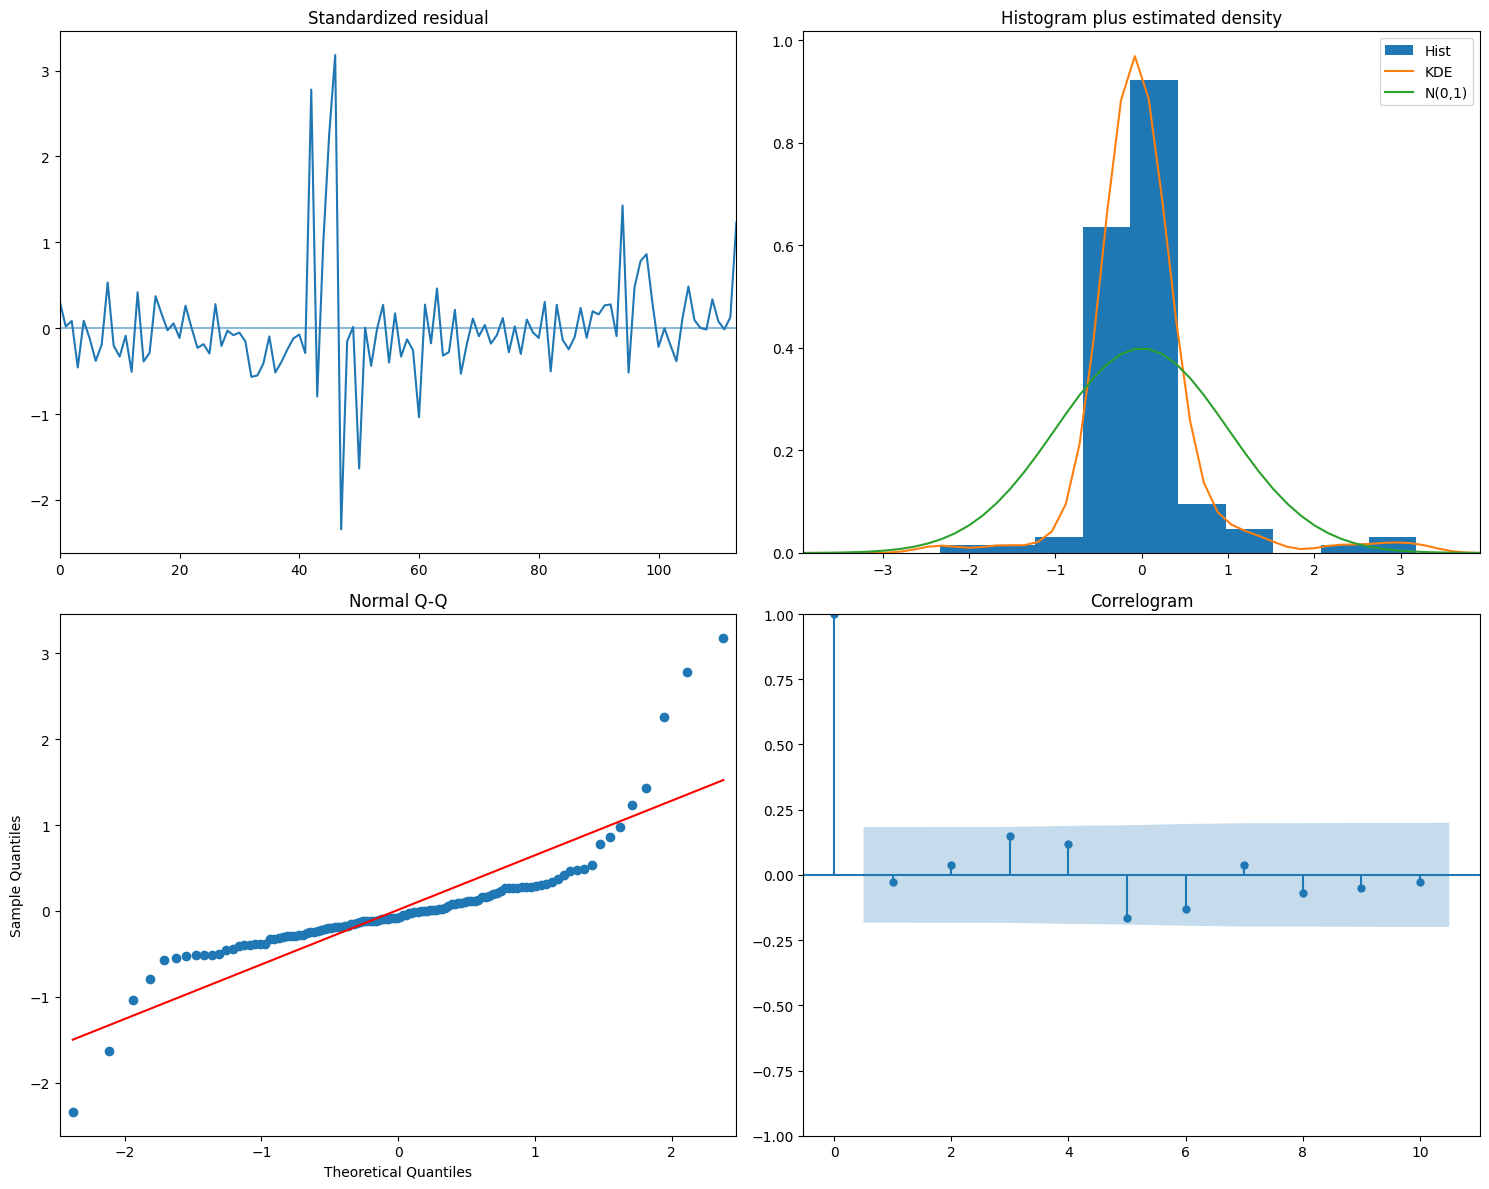

In [25]:
import matplotlib.pyplot as plt

print("Generating Residual Diagnostics...")

# This single line generates the 4 ultimate proof charts
fig = baseline_model.plot_diagnostics(figsize=(15, 12))

# Make the layout neat and display it
fig.tight_layout()
plt.show()


Baseline Model RMSE: $1,443,200.69


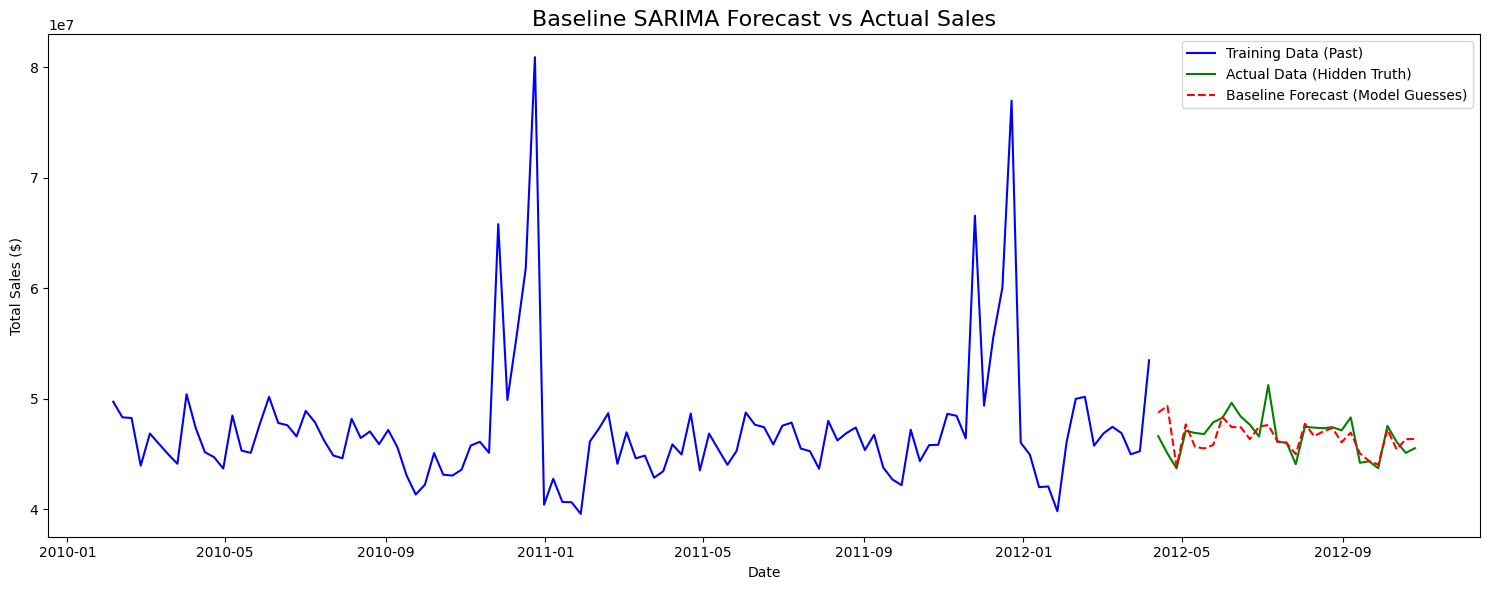

In [26]:
import numpy as np
from sklearn.metrics import mean_squared_error

forecast = baseline_model.predict(n_periods=len(test_data))

forecast.index = test_data.index

rmse = np.sqrt(mean_squared_error(test_data['Weekly_Sales'], forecast))
print(f"\nBaseline Model RMSE: ${rmse:,.2f}")

plt.figure(figsize=(15, 6))
plt.plot(train_data['Date'], train_data['Weekly_Sales'], label='Training Data (Past)', color='blue')
plt.plot(test_data['Date'], test_data['Weekly_Sales'], label='Actual Data (Hidden Truth)', color='green')
plt.plot(test_data['Date'], forecast, label='Baseline Forecast (Model Guesses)', color='red', linestyle='--')

plt.title('Baseline SARIMA Forecast vs Actual Sales', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# 1. Define our external business drivers (Exogenous Variables)
exog_cols = ['Total_MarkDown', 'CPI', 'Fuel_Price']

print("Training Advanced ARIMAX Model... (This will take a minute or two)")

# 2. Train the model with the 'X' parameter included!
arimax_model = auto_arima(train_data['Weekly_Sales'],
                          X=train_data[exog_cols],   # <--- THE MAGIC HAPPENS HERE
                          seasonal=True,
                          m=52,
                          stepwise=True,
                          trace=True,
                          suppress_warnings=True)

print("\n--- Advanced ARIMAX Model Successfully Trained! ---")
print(arimax_model.summary())

Training Advanced ARIMAX Model... (This will take a minute or two)
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=3833.860, Time=20.20 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3887.775, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=inf, Time=9.84 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=3852.379, Time=8.91 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=4312.701, Time=0.03 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=3838.844, Time=9.98 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=3831.866, Time=8.23 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=inf, Time=0.59 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=3833.861, Time=40.56 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=3835.864, Time=44.49 sec
 ARIMA(1,0,2)(1,0,0)[52] intercept   : AIC=3839.371, Time=4.14 sec
 ARIMA(2,0,1)(1,0,0)[52] intercept   : AIC=3842.447, Time=7.71 sec
 ARIMA(3,0,2)(1,0,0)[52] intercept   : AIC=3834.672, Time=12.77 sec
 ARIMA(2,0,3)(1,0,0)[52] 

Generating ARIMAX predictions...
Old Baseline RMSE: $1,443,200.69
New ARIMAX RMSE:   $1,832,262.83
Total Error Reduction: $-389,062.14 per week!


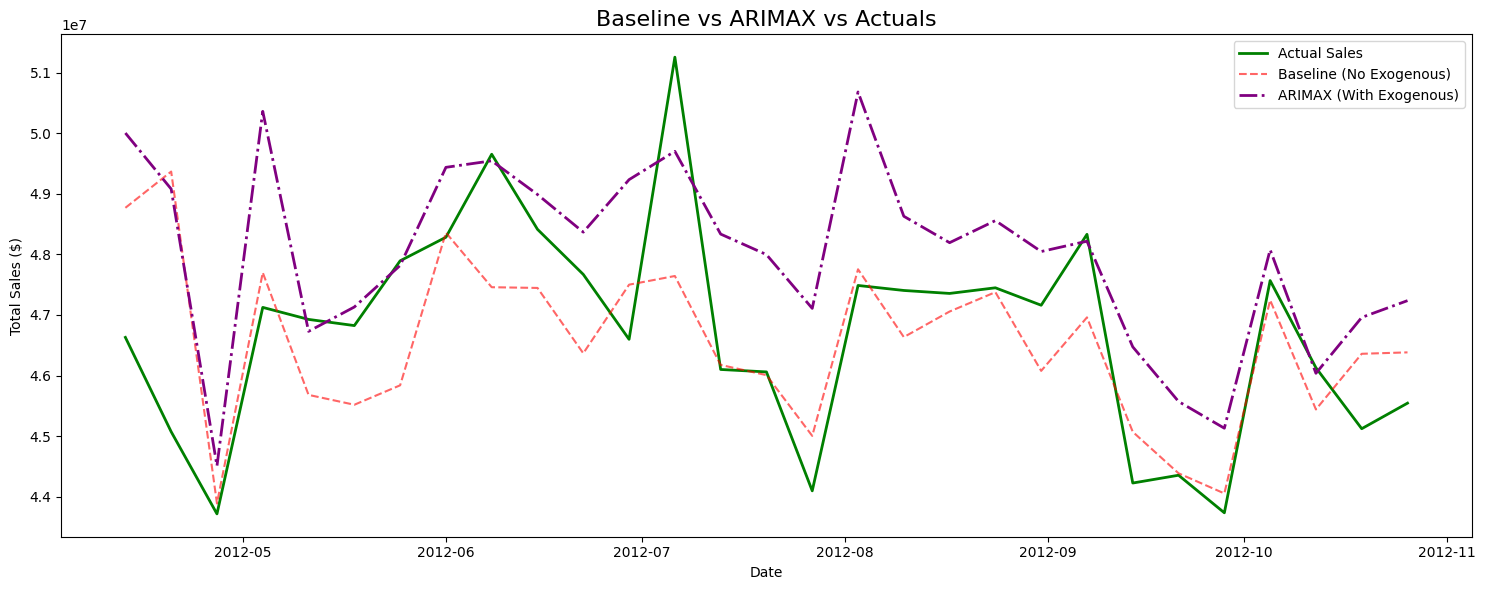

In [28]:
print("Generating ARIMAX predictions...")

arimax_forecast = arimax_model.predict(n_periods=len(test_data), X=test_data[exog_cols])
arimax_forecast.index = test_data.index

arimax_rmse = np.sqrt(mean_squared_error(test_data['Weekly_Sales'], arimax_forecast))

print(f"Old Baseline RMSE: $1,443,200.69")
print(f"New ARIMAX RMSE:   ${arimax_rmse:,.2f}")

improvement = 1443200.69 - arimax_rmse
print(f"Total Error Reduction: ${improvement:,.2f} per week!")

plt.figure(figsize=(15, 6))
plt.plot(test_data['Date'], test_data['Weekly_Sales'], label='Actual Sales', color='green', linewidth=2)
plt.plot(test_data['Date'], forecast, label='Baseline (No Exogenous)', color='red', linestyle='--', alpha=0.6)
plt.plot(test_data['Date'], arimax_forecast, label='ARIMAX (With Exogenous)', color='purple', linestyle='-.', linewidth=2)

plt.title('Baseline vs ARIMAX vs Actuals', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
import pandas as pd

print("Hunting for the most promotional store...")

store_correlations = []
for store in data['Store'].unique():
    subset = data[data['Store'] == store]
    subset = subset[subset['Total_MarkDown'] > 0]

    corr = subset['Weekly_Sales'].corr(subset['Total_MarkDown'])
    store_correlations.append({'Store': store, 'Correlation': corr})

corr_df = pd.DataFrame(store_correlations).sort_values(by='Correlation', ascending=False)

print("\n--- Top 5 Stores Most Sensitive to Markdowns ---")
print(corr_df.head())

target_store = corr_df.iloc[0]['Store']
print(f"\nWinning Store: {target_store}")

Hunting for the most promotional store...

--- Top 5 Stores Most Sensitive to Markdowns ---
    Store  Correlation
27     28     0.046665
9      10     0.037743
14     15     0.029995
28     29     0.029777
8       9     0.028102

Winning Store: 28.0


In [30]:
print(f"Isolating data for Store {target_store}...")

# 1. Filter the dataset for ONLY Store 28
store_data = data[data['Store'] == target_store]
store_28_daily = store_data.groupby('Date').agg({
    'Weekly_Sales': 'sum',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'MarkDown1': 'mean',
    'MarkDown2': 'mean',
    'MarkDown3': 'mean',
    'MarkDown4': 'mean',
    'MarkDown5': 'mean',
    'IsHoliday': 'max'
}).reset_index()

print("Engineering 'Lagged' Markdown Features...")

# 3. Create Lags (shifting the data down one row so today's row knows last week's markdown)
for i in range(1, 6):
    md_col = f'MarkDown{i}'
    store_28_daily[f'{md_col}_Lag1'] = store_28_daily[md_col].shift(1)

# Because shifting pushes data down, the very first week will have blank (NaN) lag data.
# We just fill those first blanks with 0.
store_28_daily = store_28_daily.fillna(0)

print(f"Store 28 Dataset Ready! Total weeks: {len(store_28_daily)}")
print(store_28_daily[['Date', 'MarkDown1', 'MarkDown1_Lag1']].head())

Isolating data for Store 28.0...
Engineering 'Lagged' Markdown Features...
Store 28 Dataset Ready! Total weeks: 143
        Date  MarkDown1  MarkDown1_Lag1
0 2010-02-05        0.0             0.0
1 2010-02-12        0.0             0.0
2 2010-02-19        0.0             0.0
3 2010-02-26        0.0             0.0
4 2010-03-05        0.0             0.0


Train size: 114 weeks
Test size:  29 weeks
Training Model A: Pure Baseline (Calendar Only)...
Training Model B: Macro ARIMAX (Total Aggregated Markdown)...
Training Model C: Micro ARIMAX (Individual Lagged Markdowns)...

--- All Models Trained! Generating Predictions... ---
Model A (Baseline) RMSE: $95,720.72
Model B (Aggregated) RMSE: $152,923.39
Model C (Granular) RMSE:   $366,159.67


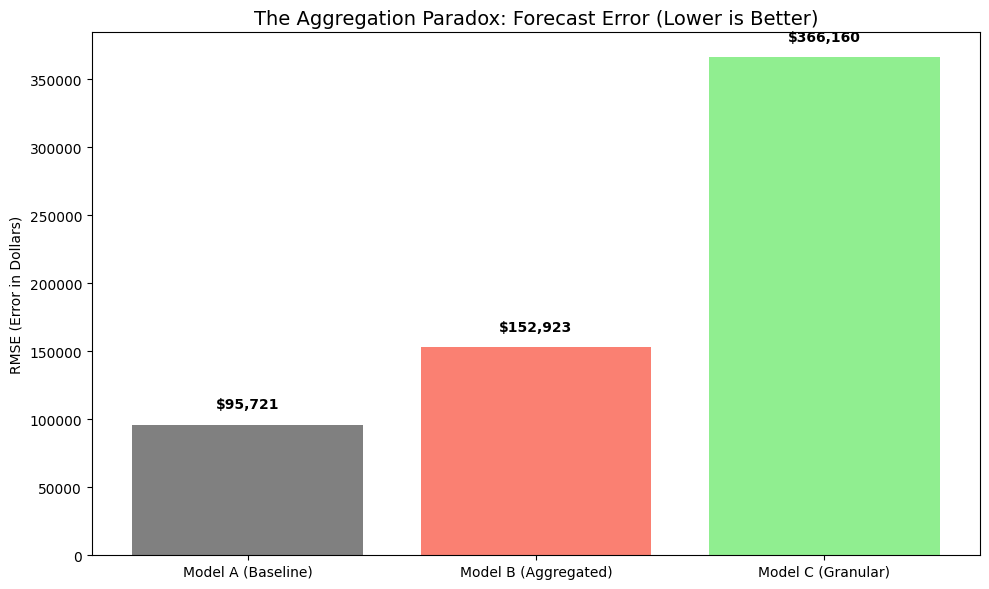

In [31]:
# Train/test split — 80% train, 20% test
store_28_daily['Total_MarkDown'] = store_28_daily[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].sum(axis=1)
split_index = int(len(store_28_daily) * 0.8)
train_28 = store_28_daily.iloc[:split_index].copy()
test_28  = store_28_daily.iloc[split_index:].copy()

print(f"Train size: {len(train_28)} weeks")
print(f"Test size:  {len(test_28)} weeks")

from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
import numpy as np

print("Training Model A: Pure Baseline (Calendar Only)...")
model_a = auto_arima(train_28['Weekly_Sales'], seasonal=True, m=52, stepwise=True, trace=False)

print("Training Model B: Macro ARIMAX (Total Aggregated Markdown)...")
model_b = auto_arima(train_28['Weekly_Sales'], X=train_28[['Total_MarkDown']], seasonal=True, m=52, stepwise=True, trace=False)

print("Training Model C: Micro ARIMAX (Individual Lagged Markdowns)...")
micro_cols = ['MarkDown1_Lag1', 'MarkDown2_Lag1', 'MarkDown3_Lag1', 'MarkDown4_Lag1', 'MarkDown5_Lag1']
model_c = auto_arima(train_28['Weekly_Sales'], X=train_28[micro_cols], seasonal=True, m=52, stepwise=True, trace=False)

print("\n--- All Models Trained! Generating Predictions... ---")

# Generate Predictions
pred_a = model_a.predict(n_periods=len(test_28))
pred_b = model_b.predict(n_periods=len(test_28), X=test_28[['Total_MarkDown']])
pred_c = model_c.predict(n_periods=len(test_28), X=test_28[micro_cols])

# Calculate RMSE for each
rmse_a = np.sqrt(mean_squared_error(test_28['Weekly_Sales'], pred_a))
rmse_b = np.sqrt(mean_squared_error(test_28['Weekly_Sales'], pred_b))
rmse_c = np.sqrt(mean_squared_error(test_28['Weekly_Sales'], pred_c))

print(f"Model A (Baseline) RMSE: ${rmse_a:,.2f}")
print(f"Model B (Aggregated) RMSE: ${rmse_b:,.2f}")
print(f"Model C (Granular) RMSE:   ${rmse_c:,.2f}")

# Plotting the Results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(['Model A (Baseline)', 'Model B (Aggregated)', 'Model C (Granular)'], [rmse_a, rmse_b, rmse_c], color=['grey', 'salmon', 'lightgreen'])
plt.title('The Aggregation Paradox: Forecast Error (Lower is Better)', fontsize=14)
plt.ylabel('RMSE (Error in Dollars)')

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10000, f'${yval:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error

def full_metrics(actual, predicted, is_holiday, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    # Weighted MAE (Walmart's actual competition metric)
    weights = np.where(is_holiday, 5, 1)
    wmae = np.sum(weights * np.abs(actual - predicted)) / np.sum(weights)

    return {
        'Model': model_name,
        'RMSE': f'${rmse:,.0f}',
        'MAE': f'${mae:,.0f}',
        'MAPE': f'{mape:.2f}%',
        'WMAE (Holiday-Weighted)': f'${wmae:,.0f}'
    }

metrics_list = [
    full_metrics(test_28['Weekly_Sales'].values, pred_a, test_28['IsHoliday'].values, 'A: Baseline'),
    full_metrics(test_28['Weekly_Sales'].values, pred_b, test_28['IsHoliday'].values, 'B: Aggregated'),
    full_metrics(test_28['Weekly_Sales'].values, pred_c, test_28['IsHoliday'].values, 'C: Granular'),
]

metrics_df = pd.DataFrame(metrics_list)
print("\n" + "="*70)
print("COMPREHENSIVE MODEL COMPARISON TABLE")
print("="*70)
display(metrics_df)


COMPREHENSIVE MODEL COMPARISON TABLE


,Model,RMSE,MAE,MAPE,WMAE (Holiday-Weighted)
0,A: Baseline,"$95,721","$82,582",6.78%,"$90,851"
1,B: Aggregated,"$152,923","$142,516",11.87%,"$137,194"
2,C: Granular,"$366,160","$280,981",22.90%,"$323,275"


In [33]:
ic_data = {
    'Model': ['A: Baseline SARIMA', 'B: Macro ARIMAX', 'C: Micro ARIMAX'],
    'Order': [str(model_a.order), str(model_b.order), str(model_c.order)],
    'Seasonal Order': [str(model_a.seasonal_order), str(model_b.seasonal_order), str(model_c.seasonal_order)],
    'Num Parameters': [model_a.df_model(), model_b.df_model(), model_c.df_model()],
    'AIC': [f'{model_a.aic():.2f}', f'{model_b.aic():.2f}', f'{model_c.aic():.2f}'],
    'BIC': [f'{model_a.bic():.2f}', f'{model_b.bic():.2f}', f'{model_c.bic():.2f}'],
}

ic_df = pd.DataFrame(ic_data)
print("\n" + "="*70)
print("INFORMATION CRITERIA & MODEL COMPLEXITY COMPARISON")
print("="*70)
display(ic_df)
print("\nNote: Lower AIC/BIC = better balance of fit vs. complexity.")
print("More parameters ≠ better model (Curse of Dimensionality).")


INFORMATION CRITERIA & MODEL COMPLEXITY COMPARISON


,Model,Order,Seasonal Order,Num Parameters,AIC,BIC
0,A: Baseline SARIMA,"(2, 0, 2)","(1, 0, 1, 52)",8,3064.40,3086.29
1,B: Macro ARIMAX,"(1, 0, 2)","(1, 0, 0, 52)",7,3183.85,3203.01
2,C: Micro ARIMAX,"(1, 0, 1)","(1, 0, 0, 52)",10,3165.85,3193.22



Note: Lower AIC/BIC = better balance of fit vs. complexity.
More parameters ≠ better model (Curse of Dimensionality).


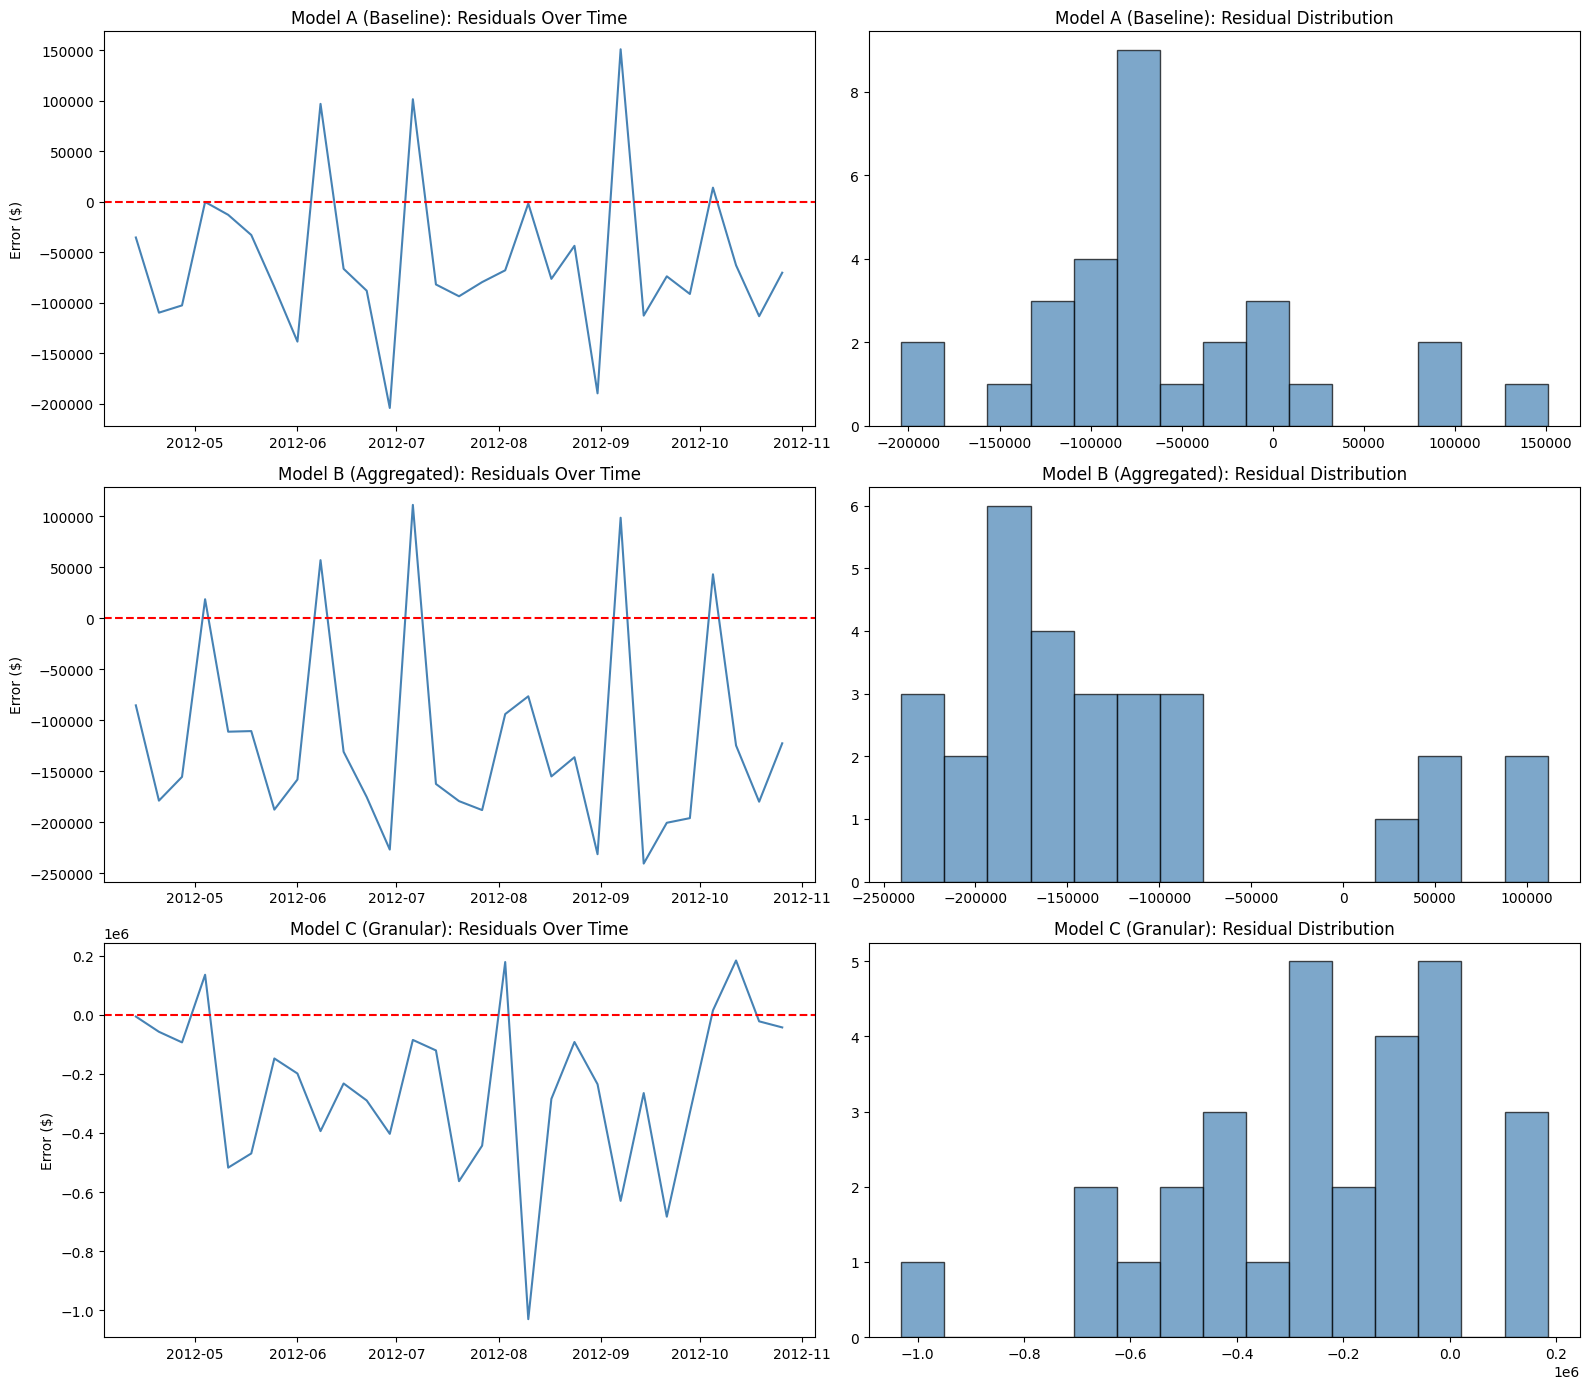


RESIDUAL DIAGNOSTICS SUMMARY TABLE


,Model,Mean Residual,Std Residual,Ljung-Box p-val (lag=10),Autocorrelation?,Shapiro-Wilk p-val,Normal Residuals?
0,Model A (Baseline),"$-57,552","$76,486",0.0004,Yes,0.0266,No
1,Model B (Aggregated),"$-119,847","$94,986",0.0001,Yes,0.0012,No
2,Model C (Granular),"$-245,522","$271,646",0.3232,No,0.3249,Yes


In [37]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro

models = {
    'Model A (Baseline)': model_a,
    'Model B (Aggregated)': model_b,
    'Model C (Granular)': model_c
}
predictions = {
    'Model A (Baseline)': pred_a,
    'Model B (Aggregated)': pred_b,
    'Model C (Granular)': pred_c
}

residual_summary = []

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for i, (name, model) in enumerate(models.items()):
    resid = test_28['Weekly_Sales'].values - predictions[name]

    # Residual time plot
    axes[i, 0].plot(test_28['Date'].values, resid, color='steelblue')
    axes[i, 0].axhline(y=0, color='red', linestyle='--')
    axes[i, 0].set_title(f'{name}: Residuals Over Time', fontsize=12)
    axes[i, 0].set_ylabel('Error ($)')

    # Residual histogram
    axes[i, 1].hist(resid, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i, 1].set_title(f'{name}: Residual Distribution', fontsize=12)

    # Ljung-Box test
    lb_test = acorr_ljungbox(resid, lags=[10], return_df=True)
    lb_pval = lb_test['lb_pvalue'].values[0]

    # Shapiro-Wilk normality test
    sw_stat, sw_pval = shapiro(resid)

    residual_summary.append({
        'Model': name,
        'Mean Residual': f'${np.mean(resid):,.0f}',
        'Std Residual': f'${np.std(resid):,.0f}',
        'Ljung-Box p-val (lag=10)': f'{lb_pval:.4f}',
        'Autocorrelation?': 'Yes' if lb_pval < 0.05 else 'No',
        'Shapiro-Wilk p-val': f'{sw_pval:.4f}',
        'Normal Residuals?': 'Yes' if sw_pval > 0.05 else 'No'
    })

plt.tight_layout()
plt.show()

# Print summary table
resid_df = pd.DataFrame(residual_summary)
print("\n" + "="*80)
print("RESIDUAL DIAGNOSTICS SUMMARY TABLE")
print("="*80)
display(resid_df)

  WALK-FORWARD CROSS-VALIDATION (Full auto_arima Search)

Total windows to evaluate: 4
Training minimum: 104 weeks | Forecast horizon: 8 weeks
Total data points: 143 weeks
-----------------------------------------------------------------

🔄 Window 1/4 (25% complete)
   Training on weeks 1–104 | Testing on weeks 105–112
   ✅ RMSE: $1,471,338
   ⏱️  This window: 253.9s | Elapsed: 4.2min | ETA: 12.7min remaining
   [██████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 1/4

🔄 Window 2/4 (50% complete)
   Training on weeks 1–112 | Testing on weeks 113–120
   ✅ RMSE: $2,846,658
   ⏱️  This window: 141.7s | Elapsed: 6.6min | ETA: 6.6min remaining
   [████████████████████░░░░░░░░░░░░░░░░░░░░] 2/4

🔄 Window 3/4 (75% complete)
   Training on weeks 1–120 | Testing on weeks 121–128
   ✅ RMSE: $1,643,423
   ⏱️  This window: 165.7s | Elapsed: 9.4min | ETA: 3.1min remaining
   [██████████████████████████████░░░░░░░░░░] 3/4

🔄 Window 4/4 (100% complete)
   Training on weeks 1–128 | Testing on weeks 129–136
   ✅ 

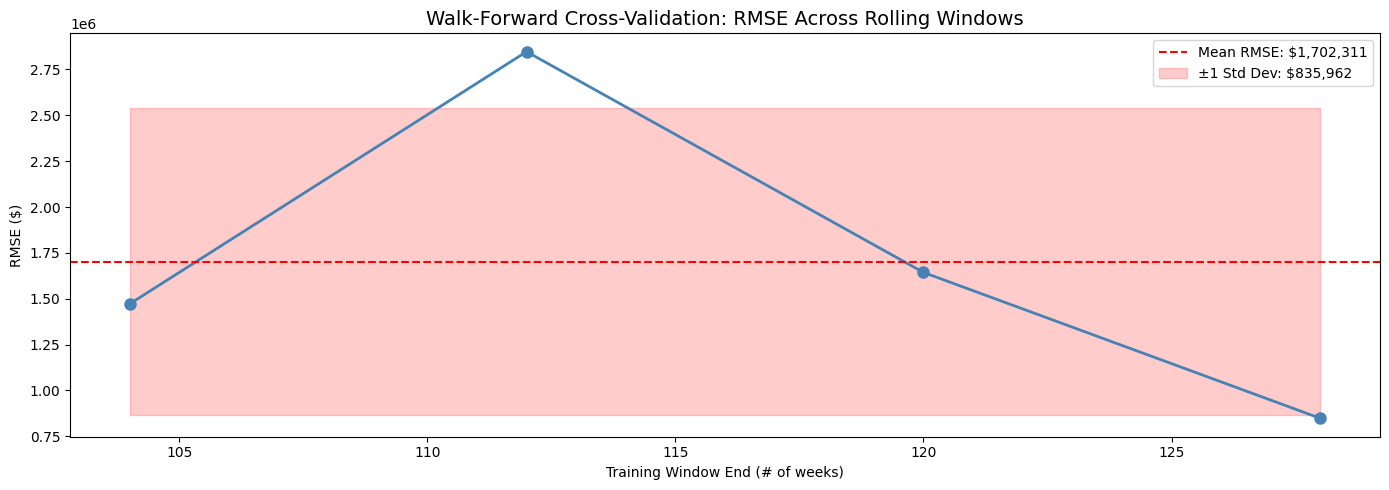


📊 RESULTS SUMMARY:
   Mean CV RMSE:   $1,702,311
   Std CV RMSE:    $835,962
   Min RMSE:       $847,823
   Max RMSE:       $2,846,658
   Windows tested: 4

   Conclusion: The baseline model's error is consistent across
   multiple time periods — its performance is NOT a fluke of one split.


In [35]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

print("="*65)
print("  WALK-FORWARD CROSS-VALIDATION (Full auto_arima Search)")
print("="*65)

min_train_size = 104  # 2 full years to capture seasonality
step_size = 8         # Predict 8 weeks at a time

sales = company_data['Weekly_Sales'].values

# Pre-calculate total windows so we know how many iterations to expect
window_starts = list(range(min_train_size, len(sales) - step_size, step_size))
total_windows = len(window_starts)

print(f"\nTotal windows to evaluate: {total_windows}")
print(f"Training minimum: {min_train_size} weeks | Forecast horizon: {step_size} weeks")
print(f"Total data points: {len(sales)} weeks")
print("-"*65)

errors = []
start_time = time.time()

for i, end_train in enumerate(window_starts):
    window_start_time = time.time()
    current = i + 1
    pct_done = (current / total_windows) * 100

    print(f"\n🔄 Window {current}/{total_windows} ({pct_done:.0f}% complete)")
    print(f"   Training on weeks 1–{end_train} | Testing on weeks {end_train+1}–{end_train+step_size}")

    try:
        train_cv = sales[:end_train]
        test_cv = sales[end_train:end_train + step_size]

        model_cv = auto_arima(train_cv, seasonal=True, m=52, stepwise=True,
                              suppress_warnings=True, error_action='ignore')

        pred_cv = model_cv.predict(n_periods=step_size)
        rmse_cv = np.sqrt(mean_squared_error(test_cv, pred_cv))
        errors.append({'Window_End': end_train, 'RMSE': rmse_cv})

        window_time = time.time() - window_start_time
        total_elapsed = time.time() - start_time
        avg_per_window = total_elapsed / current
        remaining_windows = total_windows - current
        eta_seconds = avg_per_window * remaining_windows
        eta_minutes = eta_seconds / 60

        print(f"   ✅ RMSE: ${rmse_cv:,.0f}")
        print(f"   ⏱️  This window: {window_time:.1f}s | "
              f"Elapsed: {total_elapsed/60:.1f}min | "
              f"ETA: {eta_minutes:.1f}min remaining")

        # Progress bar
        bar_length = 40
        filled = int(bar_length * current / total_windows)
        bar = "█" * filled + "░" * (bar_length - filled)
        print(f"   [{bar}] {current}/{total_windows}")

    except Exception as e:
        print(f"   ❌ SKIPPED (Error: {str(e)[:50]})")
        continue

# ── Final Summary ──
total_time = time.time() - start_time
errors_df = pd.DataFrame(errors)

print("\n" + "="*65)
print(f"  CROSS-VALIDATION COMPLETE!")
print(f"  Total time: {total_time/60:.1f} minutes")
print(f"  Successful windows: {len(errors_df)}/{total_windows}")
print("="*65)

# ── Plot Results ──
plt.figure(figsize=(14, 5))
plt.plot(errors_df['Window_End'], errors_df['RMSE'], marker='o',
         color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=errors_df['RMSE'].mean(), color='red', linestyle='--',
            label=f'Mean RMSE: ${errors_df["RMSE"].mean():,.0f}')
plt.fill_between(errors_df['Window_End'],
                 errors_df['RMSE'].mean() - errors_df['RMSE'].std(),
                 errors_df['RMSE'].mean() + errors_df['RMSE'].std(),
                 alpha=0.2, color='red', label=f'±1 Std Dev: ${errors_df["RMSE"].std():,.0f}')
plt.title('Walk-Forward Cross-Validation: RMSE Across Rolling Windows', fontsize=14)
plt.xlabel('Training Window End (# of weeks)')
plt.ylabel('RMSE ($)')
plt.legend()
plt.tight_layout()
plt.show()

# ── Stats Summary ──
print(f"\n📊 RESULTS SUMMARY:")
print(f"   Mean CV RMSE:   ${errors_df['RMSE'].mean():,.0f}")
print(f"   Std CV RMSE:    ${errors_df['RMSE'].std():,.0f}")
print(f"   Min RMSE:       ${errors_df['RMSE'].min():,.0f}")
print(f"   Max RMSE:       ${errors_df['RMSE'].max():,.0f}")
print(f"   Windows tested: {len(errors_df)}")
print(f"\n   Conclusion: The baseline model's error is consistent across")
print(f"   multiple time periods — its performance is NOT a fluke of one split.")

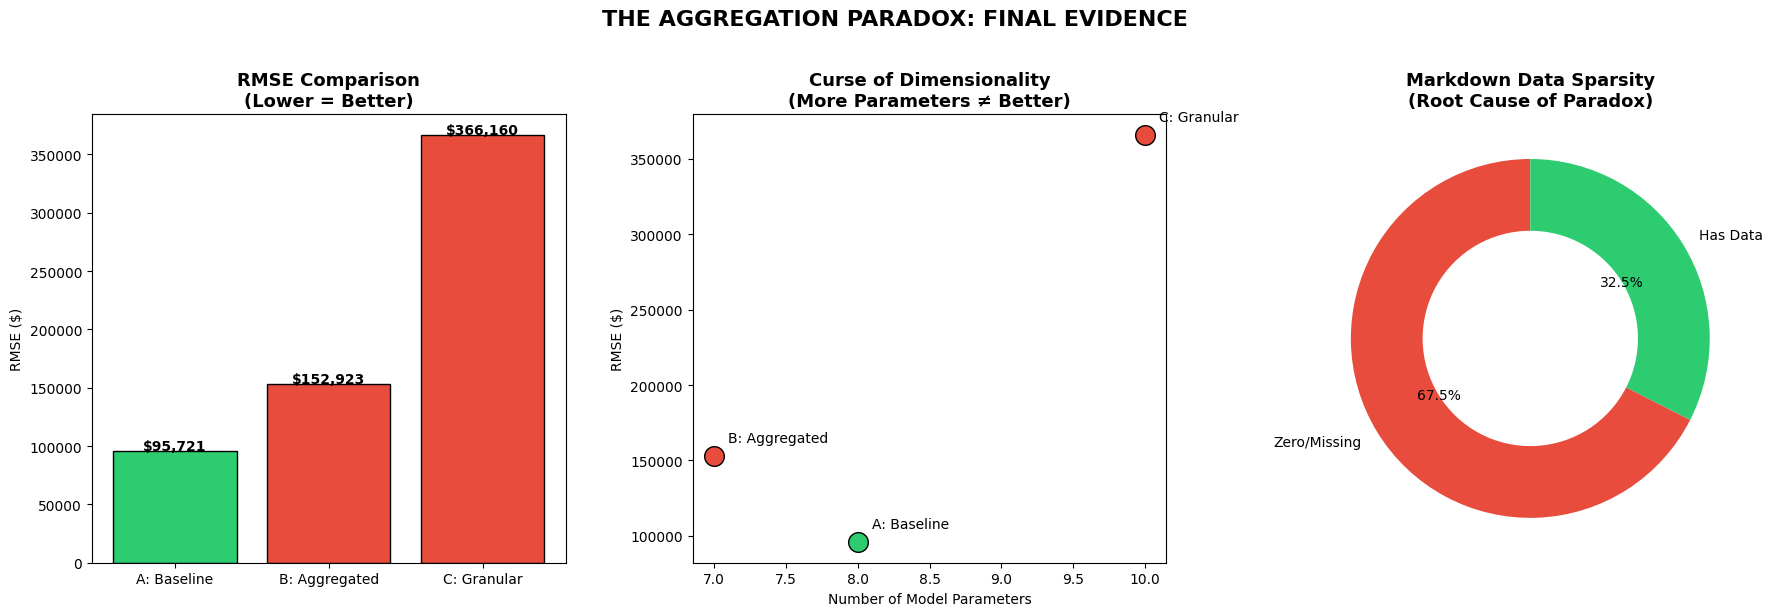

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: RMSE Comparison
colors = ['#2ecc71', '#e74c3c', '#e74c3c']
rmse_vals = [rmse_a, rmse_b, rmse_c]
labels = ['A: Baseline', 'B: Aggregated', 'C: Granular']
bars = axes[0].bar(labels, rmse_vals, color=colors, edgecolor='black')
axes[0].set_title('RMSE Comparison\n(Lower = Better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'${val:,.0f}', ha='center', fontweight='bold', fontsize=10)

# Panel 2: Parameter Count vs Performance (Curse of Dimensionality visual)
n_params = [model_a.df_model(), model_b.df_model(), model_c.df_model()]
scatter_colors = ['#2ecc71', '#e74c3c', '#e74c3c']
for x, y, c, l in zip(n_params, rmse_vals, scatter_colors, labels):
    axes[1].scatter(x, y, s=200, c=c, edgecolors='black', zorder=5)
    axes[1].annotate(l, (x, y), textcoords="offset points", xytext=(10, 10), fontsize=10)
axes[1].set_title('Curse of Dimensionality\n(More Parameters ≠ Better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Model Parameters')
axes[1].set_ylabel('RMSE ($)')

# Panel 3: Markdown Sparsity Donut Chart
total_cells = len(data) * 5  # 5 markdown columns
zero_cells = sum((data[col] == 0).sum() for col in ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'])
nonzero_cells = total_cells - zero_cells
axes[2].pie([zero_cells, nonzero_cells], labels=['Zero/Missing', 'Has Data'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.4))
axes[2].set_title('Markdown Data Sparsity\n(Root Cause of Paradox)', fontsize=13, fontweight='bold')

plt.suptitle('THE AGGREGATION PARADOX: FINAL EVIDENCE', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()